In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/processed/players_merged.csv")
print(df.shape)
print(df.duplicated(["player_id", "season"]).sum())

(4635, 36)
0


In [2]:
df["pos_clean"].value_counts().head(15)

pos_clean
D        1377
M         980
F M       870
D M       569
GK        347
F         332
D F M     152
D F         8
Name: count, dtype: int64

In [3]:
mids = df[df["pos_clean"].str.contains("M", na=False) &
          ~df["pos_clean"].str.contains("F", na=False)].copy()
mids = mids.reset_index(drop=True)
print(mids.shape)

(1549, 36)


In [4]:
mids[["player_name", "pos_clean", "team_title"]].sample(15, random_state=1)

,player_name,pos_clean,team_title
1129,Antonio Blanco,M,Alaves
1291,Jude Bellingham,M,Borussia Dortmund
1476,Bradley Locko,D M,"Brest,Reims"
1024,Daniel Boloca,M,Sassuolo
487,Bernardo Silva,M,Manchester City
916,Angel Gomes,M,Lille
361,Liam Henderson,M,Empoli
424,Issiaga Sylla,D M,Montpellier
1301,Niels Nkounkou,D M,Eintracht Frankfurt
1076,Sergi Altimira,M,Real Betis


In [5]:
%pip install matplotlib seaborn scikit-learn

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 2.9 MB/s eta 0:00:04
   -- ------------------------------------- 0.5/9.5 MB 2.9 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.5 MB 1.9 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.5 MB 2.2 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.5 MB 2.2 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/9.5 MB 2.3 MB/s eta 0:00:03
   --------------- ------------------------ 3.7/9.5 MB 2.4 MB/s eta 0:00:03
   ---------------- ----------------------- 3.9/9.5 MB 2.4 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/9.5 MB 2.4 MB/s eta 0:00:03
   -------------------- ------------------- 5.0/9.5 MB 2.4 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.5 MB 2.4 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.5 MB 2.5 MB/s eta 0:00:02
   ----------------

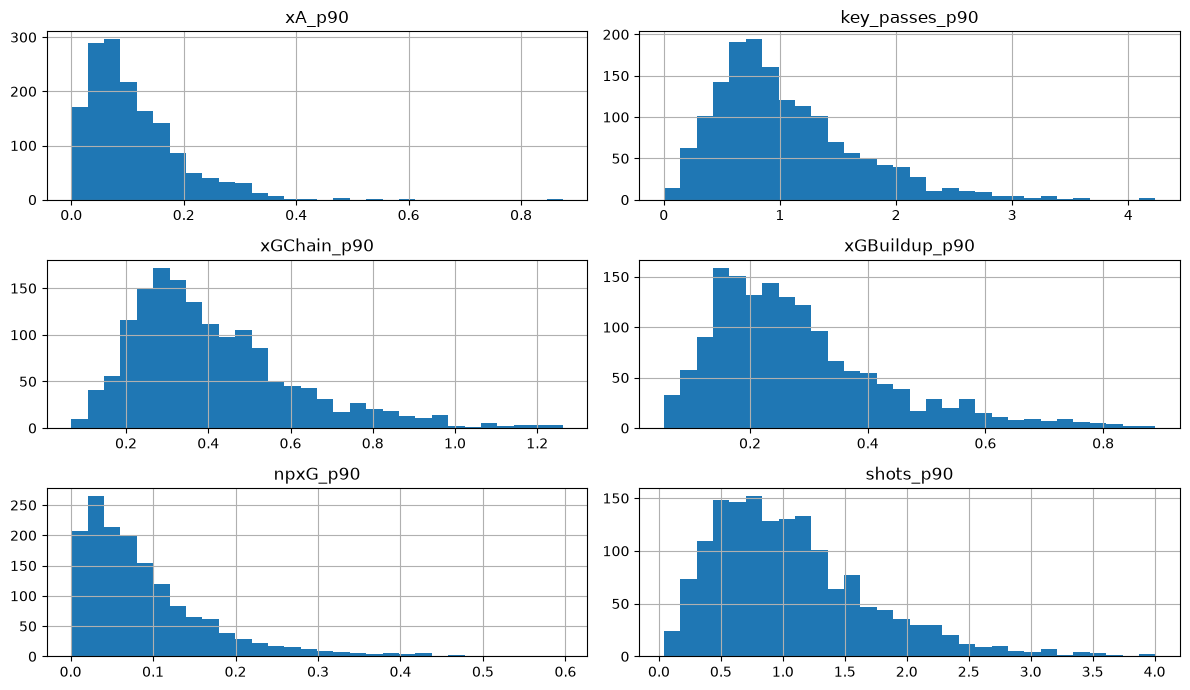

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["xA_p90", "key_passes_p90", "xGChain_p90", "xGBuildup_p90", "npxG_p90", "shots_p90"]

mids[cols].hist(bins=30, figsize=(12, 7))
plt.tight_layout()
plt.show()

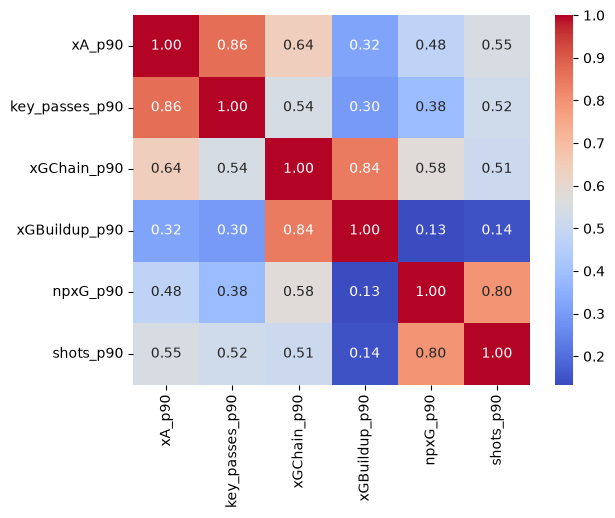

In [7]:
sns.heatmap(mids[cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [9]:
groups = {
    "creation": (["xA_p90", "key_passes_p90"], 0.35),
    "buildup":  (["xGChain_p90", "xGBuildup_p90"], 0.35),
    "scoring":  (["npxG_p90", "shots_p90"], 0.30),
}

# percentile of each stat within its season
all_metrics = [m for ms, _ in groups.values() for m in ms]
for m in all_metrics:
    mids[m + "_pct"] = mids.groupby("season")[m].rank(pct=True) * 100

# average within each group, then weight the groups
for g, (ms, w) in groups.items():
    mids[g + "_score"] = mids[[m + "_pct" for m in ms]].mean(axis=1)

mids["score"] = sum(mids[g + "_score"] * w for g, (ms, w) in groups.items())

In [10]:
top = mids[mids["season"] == 2024].sort_values("score", ascending=False)
top[["player_name", "team_title", "league", "age", "market_value", "score"]].head(15)

,player_name,team_title,league,age,market_value,score
1251,Michael Olise,Bayern Munich,Bundesliga,23.5,100000000.0,98.633396
1351,Fermín López,Barcelona,La_Liga,22.1,50000000.0,97.388060
665,Dani Olmo,Barcelona,La_Liga,27.1,60000000.0,96.888993
351,Leroy Sané,Bayern Munich,Bundesliga,29.5,32000000.0,96.641791
1287,Jamal Musiala,Bayern Munich,Bundesliga,22.3,140000000.0,96.138060
497,Kingsley Coman,Bayern Munich,Bundesliga,29.0,30000000.0,95.555037
1493,Farès Chaïbi,Eintracht Frankfurt,Bundesliga,22.6,9000000.0,94.995336
1280,Thiago Almada,Lyon,Ligue_1,24.2,25000000.0,93.931903
330,Julian Brandt,Borussia Dortmund,Bundesliga,29.2,25000000.0,92.663246
1449,Maghnes Akliouche,Monaco,Ligue_1,23.3,45000000.0,92.625933


In [11]:
print(mids.shape)
mids[["player_name", "pos_clean", "team_title"]].sample(15, random_state=1)

(1549, 46)


,player_name,pos_clean,team_title
1129,Antonio Blanco,M,Alaves
1291,Jude Bellingham,M,Borussia Dortmund
1476,Bradley Locko,D M,"Brest,Reims"
1024,Daniel Boloca,M,Sassuolo
487,Bernardo Silva,M,Manchester City
916,Angel Gomes,M,Lille
361,Liam Henderson,M,Empoli
424,Issiaga Sylla,D M,Montpellier
1301,Niels Nkounkou,D M,Eintracht Frankfurt
1076,Sergi Altimira,M,Real Betis


In [12]:
mids = df[df["pos_clean"].str.contains("M", na=False) &
          ~df["pos_clean"].str.contains("F|D", na=False)].copy()
mids = mids.reset_index(drop=True)
print(mids.shape)

groups = {
    "creation": (["xA_p90", "key_passes_p90"], 0.35),
    "buildup":  (["xGChain_p90", "xGBuildup_p90"], 0.35),
    "scoring":  (["npxG_p90", "shots_p90"], 0.30),
}

all_metrics = [m for ms, _ in groups.values() for m in ms]
for m in all_metrics:
    mids[m + "_pct"] = mids.groupby("season")[m].rank(pct=True) * 100

for g, (ms, w) in groups.items():
    mids[g + "_score"] = mids[[m + "_pct" for m in ms]].mean(axis=1)

mids["score"] = sum(mids[g + "_score"] * w for g, (ms, w) in groups.items())

(980, 36)


In [13]:
mids[["player_name", "pos_clean", "team_title"]].sample(15, random_state=2)

,player_name,pos_clean,team_title
934,Yassin Belkhdim,M,Angers
258,Will Hughes,M,Crystal Palace
318,Kingsley Coman,M,Bayern Munich
462,Walace,M,Udinese
637,Fran Beltrán,M,Celta Vigo
862,Enzo Fernández,M,Chelsea
849,Enzo Le Fée,M,Rennes
771,Matheus Henrique,M,Sassuolo
922,Benjamin Bouchouari,M,Saint-Etienne
969,Reda Belahyane,M,"Lazio,Verona"


In [14]:
top = mids[mids["season"] == 2024].sort_values("score", ascending=False)
top[["player_name", "team_title", "league", "age", "market_value", "score"]].head(15)

,player_name,team_title,league,age,market_value,score
787,Michael Olise,Bayern Munich,Bundesliga,23.5,100000000.0,98.401760
854,Fermín López,Barcelona,La_Liga,22.1,50000000.0,96.700880
225,Leroy Sané,Bayern Munich,Bundesliga,29.5,32000000.0,96.107038
426,Dani Olmo,Barcelona,La_Liga,27.1,60000000.0,96.019062
811,Jamal Musiala,Bayern Munich,Bundesliga,22.3,140000000.0,95.461877
319,Kingsley Coman,Bayern Munich,Bundesliga,29.0,30000000.0,94.787390
808,Thiago Almada,Lyon,Ligue_1,24.2,25000000.0,92.287390
919,Maghnes Akliouche,Monaco,Ligue_1,23.3,45000000.0,91.195015
209,Julian Brandt,Borussia Dortmund,Bundesliga,29.2,25000000.0,90.454545
602,Marcus Tavernier,Bournemouth,EPL,26.3,18000000.0,90.183284


In [15]:
from sklearn.neighbors import NearestNeighbors

pct_cols = [m + "_pct" for m in all_metrics]
X = mids[pct_cols].values
nn = NearestNeighbors(n_neighbors=30).fit(X)

def similar(name, season=2024, n=5):
    rows = mids[(mids["player_name"] == name) & (mids["season"] == season)]
    if rows.empty:
        return "Not found: check the spelling and the season"
    i = rows.index[0]
    pid = rows.iloc[0]["player_id"]
    dist, idx = nn.kneighbors([X[i]])
    out = mids.iloc[idx[0]].copy()
    out["distance"] = dist[0]
    out = out[out["player_id"] != pid].head(n)
    return out[["player_name", "team_title", "league", "season", "age",
                "market_value", "score", "distance"]]

similar("Martin Odegaard")

,player_name,team_title,league,season,age,market_value,score,distance
209,Julian Brandt,Borussia Dortmund,Bundesliga,2024,29.2,25000000.0,90.454545,8.822058
812,Osame Sahraoui,Lille,Ligue_1,2024,24.1,12000000.0,86.334311,12.568985
788,Xavi Simons,RasenBallsport Leipzig,Bundesliga,2023,21.2,80000000.0,91.471963,13.530223
137,Luis Alberto,Lazio,Serie_A,2022,30.8,18000000.0,85.440252,14.026751
428,James Maddison,Tottenham,EPL,2023,27.6,70000000.0,92.928349,14.242585


In [16]:
cand = mids[(mids["season"] == 2024) &
            (mids["age"] <= 24) &
            (mids["market_value"].notna())].copy()

cand["score_per_million"] = cand["score"] / (cand["market_value"] / 1e6)
cand = cand[cand["score"] >= 75]

cand.sort_values("score_per_million", ascending=False)[
    ["player_name", "team_title", "league", "age", "market_value", "score", "score_per_million"]
].head(15)

,player_name,team_title,league,age,market_value,score,score_per_million
752,Lazar Samardzic,Atalanta,Serie_A,23.3,17000000.0,87.697947,5.158703
728,Paul Nebel,Mainz 05,Bundesliga,22.7,24000000.0,77.250733,3.218781
935,Ben Seghir,Monaco,Ligue_1,20.4,28000000.0,89.222874,3.186531
791,Yeremi Pino,Villarreal,La_Liga,22.7,30000000.0,76.370968,2.545699
796,Enzo Millot,VfB Stuttgart,Bundesliga,23.0,35000000.0,78.760997,2.250314
919,Maghnes Akliouche,Monaco,Ligue_1,23.3,45000000.0,91.195015,2.026556
854,Fermín López,Barcelona,La_Liga,22.1,50000000.0,96.700880,1.934018
789,Xavi Simons,RasenBallsport Leipzig,Bundesliga,22.2,70000000.0,83.856305,1.197947
906,Nico Williams,Athletic Club,La_Liga,23.0,70000000.0,79.765396,1.139506
787,Michael Olise,Bayern Munich,Bundesliga,23.5,100000000.0,98.401760,0.984018


In [17]:
mids.to_csv("data/processed/midfielders_scored.csv", index=False)